Prophet version: 1.3.0
✅ barcelona    | jun2025 |  2,303,883 filas
✅ barcelona    | sep2025 |  7,084,654 filas
✅ euskadi      | jun2025 |  2,610,121 filas
✅ euskadi      | sep2025 |  2,311,910 filas
✅ girona       | jun2025 |  8,196,442 filas
✅ girona       | sep2025 |  6,230,128 filas
✅ girona       | dic2025 |  6,230,128 filas
✅ madrid       | jun2025 |  9,491,474 filas
✅ madrid       | sep2025 |  9,125,007 filas
✅ malaga       | jun2025 |  3,544,151 filas
✅ malaga       | sep2025 |  3,545,610 filas
✅ mallorca     | jun2025 |  6,246,250 filas
✅ mallorca     | sep2025 |  5,487,410 filas
✅ menorca      | jun2025 |  1,442,115 filas
✅ menorca      | sep2025 |  1,342,835 filas
✅ sevilla      | jun2025 |  3,037,899 filas
✅ sevilla      | sep2025 |  2,998,475 filas
✅ valencia     | jun2025 |          0 filas
✅ valencia     | sep2025 |  2,863,060 filas

Calendario total: 84,091,552 filas
Columnas: ['listing_id', 'date', 'available', 'price', 'adjusted_price', 'minimum_nights', 'maximum_night

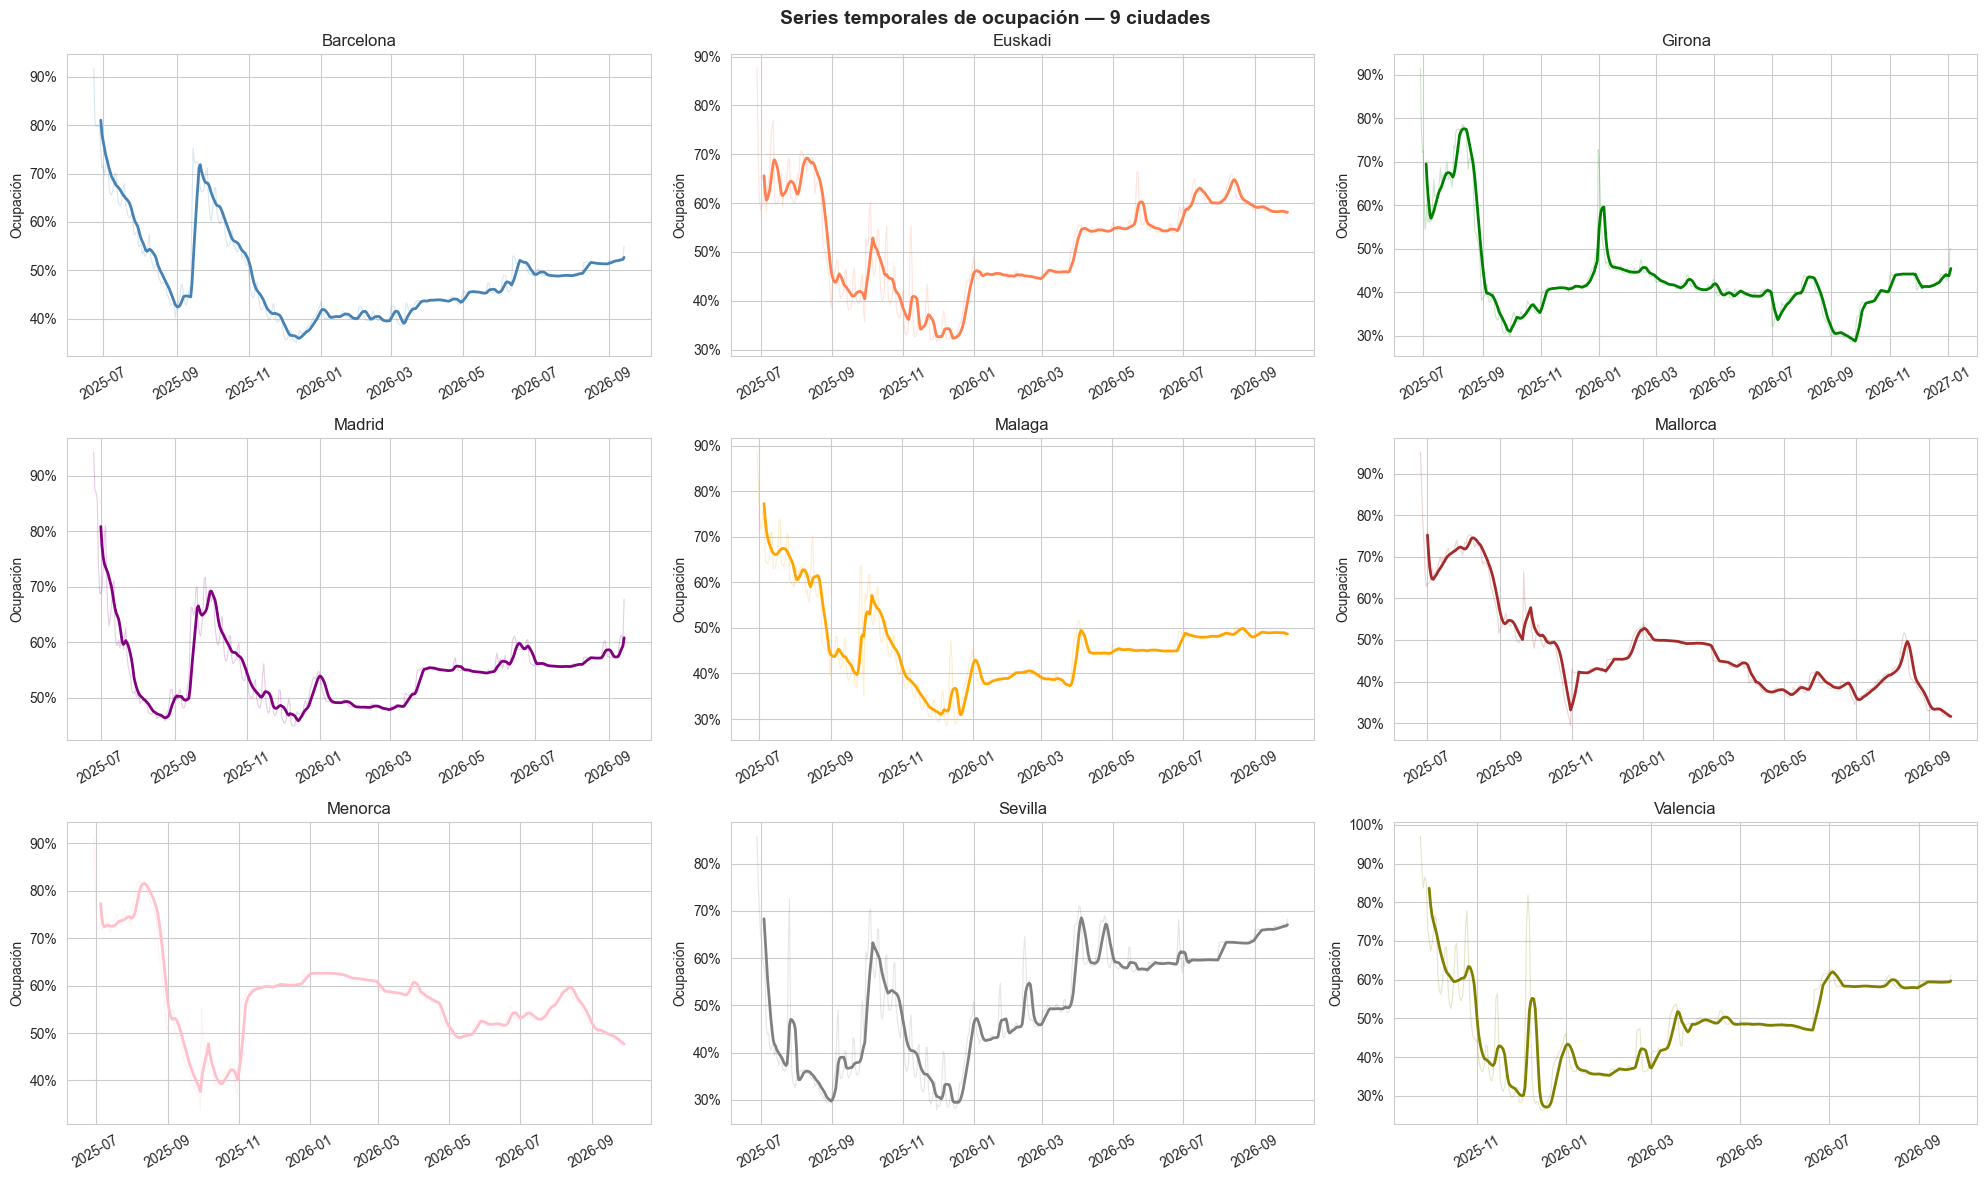


--- Barcelona ---


21:01:29 - cmdstanpy - INFO - Chain [1] start processing
21:01:31 - cmdstanpy - INFO - Chain [1] done processing
21:01:31 - cmdstanpy - INFO - Chain [1] start processing
21:01:31 - cmdstanpy - INFO - Chain [1] done processing
21:01:31 - cmdstanpy - INFO - Chain [1] start processing
21:01:31 - cmdstanpy - INFO - Chain [1] done processing


  Días entrenamiento: 389
  MAE test (60 días): 0.1212 (12.1 pp)

--- Euskadi ---
  Días entrenamiento: 399
  MAE test (60 días): 0.1162 (11.6 pp)

--- Girona ---


21:01:31 - cmdstanpy - INFO - Chain [1] start processing
21:01:31 - cmdstanpy - INFO - Chain [1] done processing
21:01:31 - cmdstanpy - INFO - Chain [1] start processing
21:01:31 - cmdstanpy - INFO - Chain [1] done processing


  Días entrenamiento: 496
  MAE test (60 días): 0.1501 (15.0 pp)

--- Madrid ---
  Días entrenamiento: 387
  MAE test (60 días): 0.1141 (11.4 pp)

--- Malaga ---


...

  Días entrenamiento: 398
  MAE test (60 días): 0.0821 (8.2 pp)

--- Mallorca ---
  Días entrenamiento: 393
  MAE test (60 días): 0.0164 (1.6 pp)

--- Menorca ---


21:01:31 - cmdstanpy - INFO - Chain [1] start processing
21:01:31 - cmdstanpy - INFO - Chain [1] done processing
21:01:31 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:01:31 - cmdstanpy - INFO - Chain [1] start processing


  Días entrenamiento: 398
  MAE test (60 días): 0.0881 (8.8 pp)

--- Sevilla ---


21:01:33 - cmdstanpy - INFO - Chain [1] done processing
21:01:33 - cmdstanpy - INFO - Chain [1] start processing
21:01:33 - cmdstanpy - INFO - Chain [1] done processing


  Días entrenamiento: 399
  MAE test (60 días): 0.1727 (17.3 pp)

--- Valencia ---
  Días entrenamiento: 306
  MAE test (60 días): 0.1749 (17.5 pp)

✅ Modelos entrenados: 9/9


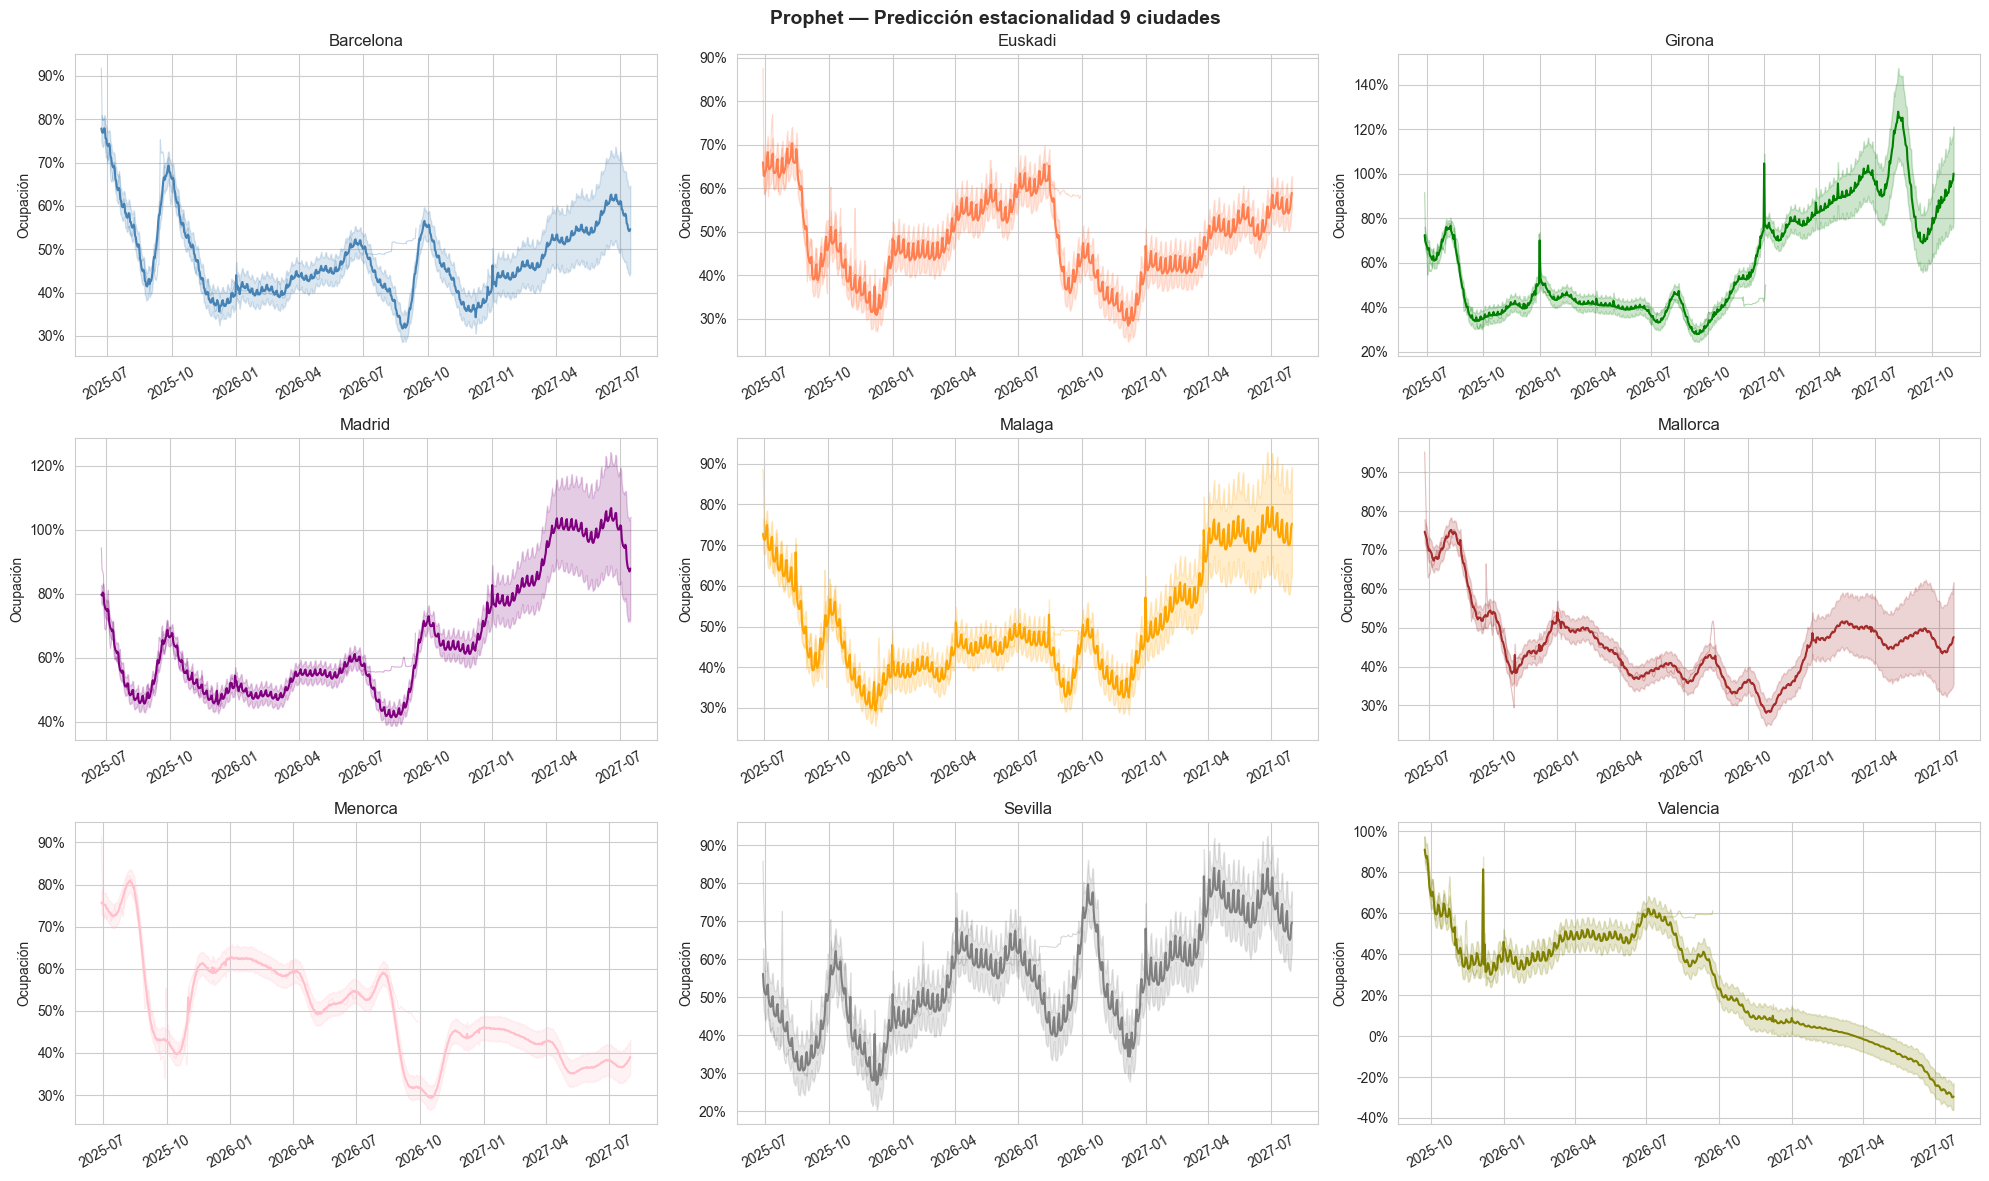

=== MÉTRICAS PROPHET POR CIUDAD ===
Ciudad       |      MAE |   MAE (pp) |   Días
---------------------------------------------
barcelona    |   0.1212 |     12.1 pp |    449
euskadi      |   0.1162 |     11.6 pp |    459
girona       |   0.1501 |     15.0 pp |    556
madrid       |   0.1141 |     11.4 pp |    447
malaga       |   0.0821 |      8.2 pp |    458
mallorca     |   0.0164 |      1.6 pp |    453
menorca      |   0.0881 |      8.8 pp |    458
sevilla      |   0.1727 |     17.3 pp |    459
valencia     |   0.1749 |     17.5 pp |    366
✅ barcelona    guardado (55 KB)
✅ euskadi      guardado (55 KB)
✅ girona       guardado (64 KB)
✅ madrid       guardado (54 KB)
✅ malaga       guardado (55 KB)
✅ mallorca     guardado (55 KB)
✅ menorca      guardado (55 KB)
✅ sevilla      guardado (55 KB)
✅ valencia     guardado (46 KB)

✅ Métricas guardadas: /Users/ivannavarrosuero/tfm_vut/src/models/metricas_prophet.pkl

--- Archivos en src/models/ ---
   encoders_ocupacion.pkl                

In [1]:
# %%
# ============================================================
# CELDA 1 — Imports y carga de datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
REPORTS   = os.path.join(BASE, 'reports')
MODELS    = os.path.join(BASE, 'src', 'models')
RAW       = os.path.join(BASE, 'data', 'raw')

import prophet
print(f"Prophet version: {prophet.__version__}")

# %%
# ============================================================
# CELDA 2 — Carga calendarios de las 9 ciudades
# ============================================================

CIUDADES = {
    'barcelona': ['jun2025', 'sep2025'],
    'euskadi':   ['jun2025', 'sep2025'],
    'girona':    ['jun2025', 'sep2025', 'dic2025'],
    'madrid':    ['jun2025', 'sep2025'],
    'malaga':    ['jun2025', 'sep2025'],
    'mallorca':  ['jun2025', 'sep2025'],
    'menorca':   ['jun2025', 'sep2025'],
    'sevilla':   ['jun2025', 'sep2025'],
    'valencia':  ['jun2025', 'sep2025'],
}

dfs = []
for ciudad, periodos in CIUDADES.items():
    for periodo in periodos:
        ruta = os.path.join(RAW, ciudad, periodo, 'calendar.csv.gz')
        if os.path.exists(ruta):
            df_tmp = pd.read_csv(ruta, compression='gzip', low_memory=False)
            df_tmp['ciudad']       = ciudad
            df_tmp['fecha_scrape'] = periodo
            dfs.append(df_tmp)
            print(f"✅ {ciudad:12} | {periodo} | {len(df_tmp):10,} filas")
        else:
            print(f"❌ {ciudad:12} | {periodo} | NO ENCONTRADO")

cal = pd.concat(dfs, ignore_index=True)
print(f"\nCalendario total: {len(cal):,} filas")
print(f"Columnas: {list(cal.columns)}")

# %%
# ============================================================
# CELDA 3 — Agregación diaria por ciudad
# ============================================================

cal['ocupado'] = (cal['available'] == 'f').astype(int)
cal['date']    = pd.to_datetime(cal['date'])
cal            = cal[cal['date'] >= '2024-01-01']

ocupacion_diaria = (cal.groupby(['ciudad', 'date'])['ocupado']
                    .mean()
                    .reset_index())
ocupacion_diaria.columns = ['ciudad', 'ds', 'y']

print("Series temporales generadas:")
for ciudad in sorted(ocupacion_diaria['ciudad'].unique()):
    datos = ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad]
    print(f"  {ciudad:12} | {datos['ds'].min().date()} → {datos['ds'].max().date()} "
          f"| {len(datos):4} días | ocup. media: {datos['y'].mean():.1%}")

# %%
# ============================================================
# CELDA 4 — Visualización series temporales (resumen)
# ============================================================

ciudades_lista = sorted(ocupacion_diaria['ciudad'].unique())
colores = ['steelblue','coral','green','purple','orange',
           'brown','pink','gray','olive']

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, ciudad in enumerate(ciudades_lista):
    datos = (ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad]
             .sort_values('ds').copy())
    datos['media_movil'] = datos['y'].rolling(7).mean()
    
    axes[idx].plot(datos['ds'], datos['y'], alpha=0.2,
                   color=colores[idx], linewidth=0.8)
    axes[idx].plot(datos['ds'], datos['media_movil'],
                   color=colores[idx], linewidth=2)
    axes[idx].set_title(ciudad.capitalize())
    axes[idx].set_ylabel('Ocupación')
    axes[idx].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('Series temporales de ocupación — 9 ciudades',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'series_temporales.png'), dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# CELDA 5 — Entrenamiento Prophet para las 9 ciudades
# ============================================================

modelos_prophet     = {}
predicciones_prophet = {}
metricas_prophet    = {}

for ciudad in ciudades_lista:
    print(f"\n--- {ciudad.capitalize()} ---")

    datos = (ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad]
             .sort_values('ds').reset_index(drop=True))

    if len(datos) < 90:
        print(f"  ⚠️ Solo {len(datos)} días — insuficiente, saltando")
        continue

    train = datos[:-60]
    test  = datos[-60:]

    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10,
    )
    modelo.add_country_holidays(country_name='ES')
    modelo.fit(train)

    futuro   = modelo.make_future_dataframe(periods=365)
    forecast = modelo.predict(futuro)

    pred_test = forecast[forecast['ds'].isin(test['ds'])]['yhat'].values
    mae = mean_absolute_error(test['y'].values, pred_test)

    print(f"  Días entrenamiento: {len(train)}")
    print(f"  MAE test (60 días): {mae:.4f} ({mae*100:.1f} pp)")

    modelos_prophet[ciudad]      = modelo
    predicciones_prophet[ciudad] = forecast
    metricas_prophet[ciudad]     = {'mae': mae, 'n_dias': len(datos)}

print(f"\n✅ Modelos entrenados: {len(modelos_prophet)}/9")

# %%
# ============================================================
# CELDA 6 — Visualización predicciones (cuadrícula 3x3)
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, ciudad in enumerate(ciudades_lista):
    if ciudad not in predicciones_prophet:
        continue

    datos    = (ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad]
                .sort_values('ds'))
    forecast = predicciones_prophet[ciudad]
    color    = colores[idx]

    axes[idx].plot(datos['ds'], datos['y'], alpha=0.3,
                   color=color, linewidth=0.8, label='Real')
    axes[idx].plot(forecast['ds'], forecast['yhat'],
                   color=color, linewidth=1.5, label='Predicción')
    axes[idx].fill_between(forecast['ds'],
                           forecast['yhat_lower'],
                           forecast['yhat_upper'],
                           alpha=0.2, color=color)
    axes[idx].set_title(ciudad.capitalize())
    axes[idx].set_ylabel('Ocupación')
    axes[idx].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('Prophet — Predicción estacionalidad 9 ciudades',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'prophet_predicciones.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# CELDA 7 — Resumen de métricas
# ============================================================

print("=== MÉTRICAS PROPHET POR CIUDAD ===")
print(f"{'Ciudad':12} | {'MAE':>8} | {'MAE (pp)':>10} | {'Días':>6}")
print("-" * 45)
for ciudad, m in sorted(metricas_prophet.items()):
    print(f"{ciudad:12} | {m['mae']:8.4f} | {m['mae']*100:8.1f} pp | {m['n_dias']:6}")

# %%
# ============================================================
# CELDA 8 — Guardado de modelos y métricas
# ============================================================

for ciudad in ciudades_lista:
    if ciudad not in modelos_prophet:
        continue

    ruta_modelo = os.path.join(MODELS, f'prophet_{ciudad}.pkl')
    with open(ruta_modelo, 'wb') as f:
        pickle.dump(modelos_prophet[ciudad], f)

    ruta_forecast = os.path.join(MODELS, f'prophet_forecast_{ciudad}.pkl')
    with open(ruta_forecast, 'wb') as f:
        pickle.dump(predicciones_prophet[ciudad], f)

    tam = os.path.getsize(ruta_modelo) / 1024
    print(f"✅ {ciudad:12} guardado ({tam:.0f} KB)")

ruta_metricas = os.path.join(MODELS, 'metricas_prophet.pkl')
with open(ruta_metricas, 'wb') as f:
    pickle.dump(metricas_prophet, f)

print(f"\n✅ Métricas guardadas: {ruta_metricas}")
print(f"\n--- Archivos en src/models/ ---")
for f in sorted(os.listdir(MODELS)):
    tam = os.path.getsize(os.path.join(MODELS, f)) / 1024
    print(f"   {f:45} {tam:8.0f} KB")